In [2]:
import pandas as pd
df_book= pd.read_csv(r'C:\projects_monish\Hotel Analytics\Hotel-analytics\data\raw\fact_bookings.csv')
df_book

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-2022,01-05-2022,02-05-2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-2022,01-05-2022,02-05-2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-2022,01-05-2022,04-05-2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-2022,01-05-2022,02-05-2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,27-04-2022,01-05-2022,02-05-2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
...,...,...,...,...,...,...,...,...,...,...,...,...
134585,Jul312217564RT46,17564,29-07-2022,31-07-2022,03-08-2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134586,Jul312217564RT47,17564,30-07-2022,31-07-2022,01-08-2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760
134587,Jul312217564RT48,17564,30-07-2022,31-07-2022,02-08-2022,1.0,RT4,tripster,NaN,Cancelled,32300,12920
134588,Jul312217564RT49,17564,29-07-2022,31-07-2022,01-08-2022,2.0,RT4,logtrip,2.0,Checked Out,32300,32300


In [3]:
df_book.info()

<class 'pandas.DataFrame'>
RangeIndex: 134590 entries, 0 to 134589
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134590 non-null  str    
 1   property_id        134590 non-null  int64  
 2   booking_date       134590 non-null  str    
 3   check_in_date      134590 non-null  str    
 4   checkout_date      134590 non-null  str    
 5   no_guests          134587 non-null  float64
 6   room_category      134590 non-null  str    
 7   booking_platform   134590 non-null  str    
 8   ratings_given      56683 non-null   float64
 9   booking_status     134590 non-null  str    
 10  revenue_generated  134590 non-null  int64  
 11  revenue_realized   134590 non-null  int64  
dtypes: float64(2), int64(3), str(7)
memory usage: 12.3 MB


In [27]:
df_book.describe()

,property_id,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2.036170,3.619004,1.537805e+04,12696.123256
std,1093.055847,1.034885,1.235009,9.303604e+04,6928.108124
min,16558.000000,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,6.000000,5.000000,2.856000e+07,45220.000000


In [4]:
df_book.shape

(134590, 12)

In [5]:
df_book.room_category.unique()

<StringArray>
['RT1', 'RT2', 'RT3', 'RT4']
Length: 4, dtype: str

In [6]:
df_book.property_id.unique()

array([16558, 16559, 16560, 16561, 16562, 16563, 17558, 17559, 17560,
       17561, 17562, 17563, 18558, 18559, 18560, 18561, 18562, 18563,
       19558, 19559, 19560, 19561, 19562, 19563, 17564])

In [7]:
df_book.booking_platform.value_counts() 

booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64

<Axes: xlabel='booking_platform'>

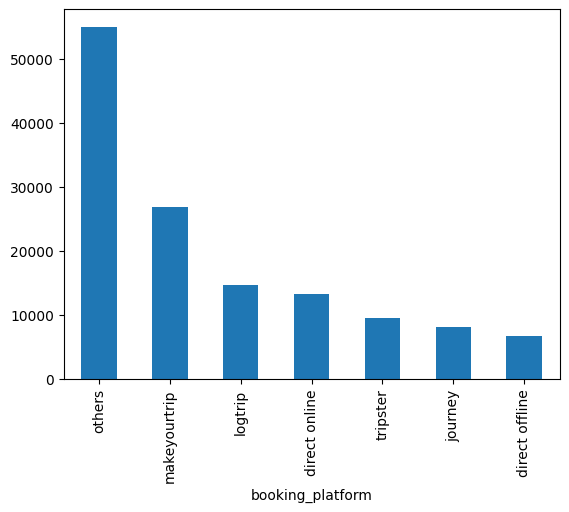

In [8]:
df_book.booking_platform.value_counts().plot(kind='bar')

<Axes: ylabel='booking_platform'>

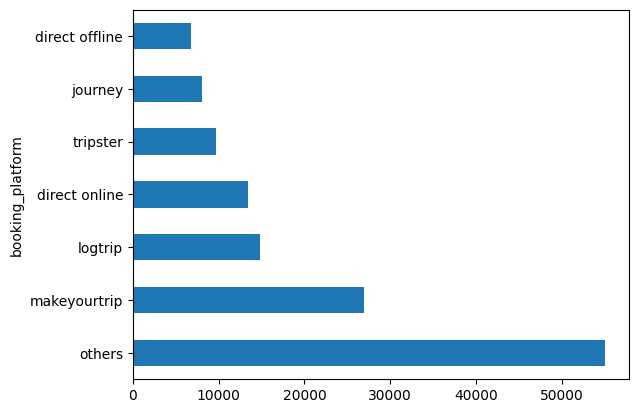

In [9]:
df_book.booking_platform.value_counts().plot(kind='barh')

<Axes: xlabel='booking_platform'>

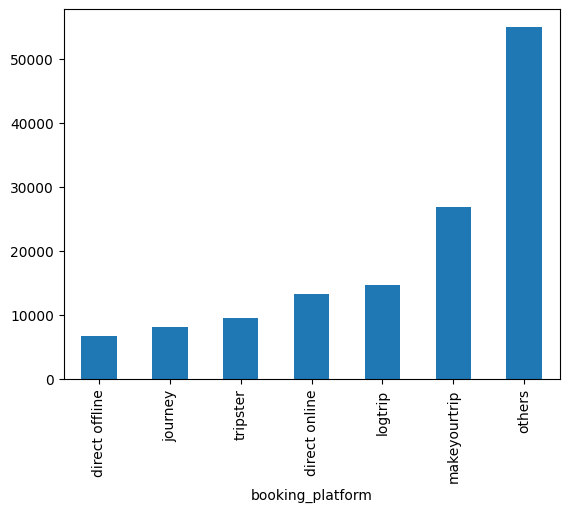

In [10]:
df_book.booking_platform.value_counts().sort_values().plot(kind='bar')

In [12]:
df_book.revenue_generated.max(),df_book.revenue_generated.min()

(np.int64(28560000), np.int64(6500))

In [13]:
df_book.property_id.value_counts()

property_id
16559    7338
18562    7333
16563    7147
18560    6638
18561    6458
17563    6337
17559    6142
17560    6013
19560    5979
19562    5812
19561    5736
19563    5413
18559    5256
17561    5183
17558    5036
16562    4820
18563    4728
19559    4705
16560    4693
18558    4475
16561    4418
19558    4371
17564    3982
17562    3424
16558    3153
Name: count, dtype: int64

In [14]:
df_book.groupby('property_id').size()

property_id
16558    3153
16559    7338
16560    4693
16561    4418
16562    4820
16563    7147
17558    5036
17559    6142
17560    6013
17561    5183
17562    3424
17563    6337
17564    3982
18558    4475
18559    5256
18560    6638
18561    6458
18562    7333
18563    4728
19558    4371
19559    4705
19560    5979
19561    5736
19562    5812
19563    5413
dtype: int64

In [15]:
df=df_book.groupby(['property_id', 'booking_status']).size().unstack()
df

booking_status,Cancelled,Checked Out,No Show
property_id,,,
16558,790,2208,155
16559,1806,5164,368
16560,1132,3338,223
16561,1127,3087,204
16562,1218,3340,262
16563,1805,5002,340
17558,1292,3521,223
17559,1475,4349,318
17560,1507,4182,324


In [16]:
result = df[df['Checked Out'] > df['Cancelled']]
result

booking_status,Cancelled,Checked Out,No Show
property_id,,,
16558,790,2208,155
16559,1806,5164,368
16560,1132,3338,223
16561,1127,3087,204
16562,1218,3340,262
16563,1805,5002,340
17558,1292,3521,223
17559,1475,4349,318
17560,1507,4182,324


In [17]:
df_checked = df_book[df_book['booking_status'] == 'Checked Out']
df_checked

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-2022,01-05-2022,02-05-2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
2,May012216558RT13,16558,28-04-2022,01-05-2022,04-05-2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
4,May012216558RT15,16558,27-04-2022,01-05-2022,02-05-2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920
5,May012216558RT16,16558,01-05-2022,01-05-2022,03-05-2022,2.0,RT1,others,4.0,Checked Out,9100,9100
8,May012216558RT19,16558,30-04-2022,01-05-2022,02-05-2022,2.0,RT1,tripster,NaN,Checked Out,9100,9100
...,...,...,...,...,...,...,...,...,...,...,...,...
134582,Jul312217564RT43,17564,31-07-2022,31-07-2022,03-08-2022,1.0,RT4,others,1.0,Checked Out,32300,32300
134584,Jul312217564RT45,17564,30-07-2022,31-07-2022,01-08-2022,2.0,RT4,others,2.0,Checked Out,32300,32300
134585,Jul312217564RT46,17564,29-07-2022,31-07-2022,03-08-2022,1.0,RT4,makeyourtrip,2.0,Checked Out,32300,32300
134586,Jul312217564RT47,17564,30-07-2022,31-07-2022,01-08-2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760


In [18]:
df1=df_checked.groupby('property_id').size()
df1

property_id
16558    2208
16559    5164
16560    3338
16561    3087
16562    3340
16563    5002
17558    3521
17559    4349
17560    4182
17561    3627
17562    2384
17563    4478
17564    2811
18558    3124
18559    3711
18560    4712
18561    4550
18562    5146
18563    3292
19558    3061
19559    3333
19560    4133
19561    4003
19562    4095
19563    3760
dtype: int64

In [19]:
max_property = df1.idxmax()
max_value = df1.max()
print(max_property, max_value)

16559 5164


In [20]:
df1.idxmax()

np.int64(16559)

In [21]:
df_abook=pd.read_csv(r"C:\projects_monish\Hotel Analytics\Hotel-analytics\data\raw\fact_aggregated_bookings.csv")
df_abook

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,01-05-2022,RT1,25,30.0
1,19562,01-05-2022,RT1,28,30.0
2,19563,01-05-2022,RT1,23,30.0
3,17558,01-05-2022,RT1,30,19.0
4,16558,01-05-2022,RT1,18,19.0
...,...,...,...,...,...
9195,16563,31-07-2022,RT4,13,18.0
9196,16559,31-07-2022,RT4,13,18.0
9197,17558,31-07-2022,RT4,3,6.0
9198,19563,31-07-2022,RT4,3,6.0


In [22]:
#Find out unique property ids in aggregate bookings dataset
df_abook.property_id.unique()

array([16559, 19562, 19563, 17558, 16558, 17560, 19558, 19560, 17561,
       16560, 16561, 16562, 16563, 17559, 17562, 17563, 18558, 18559,
       18561, 18562, 18563, 19559, 19561, 17564, 18560])

In [23]:
#Find out total bookings per property_id
df_abook.groupby('property_id')['successful_bookings'].sum()

property_id
16558    3153
16559    7338
16560    4693
16561    4418
16562    4820
16563    7211
17558    5053
17559    6142
17560    6013
17561    5183
17562    3424
17563    6337
17564    3982
18558    4475
18559    5256
18560    6638
18561    6458
18562    7333
18563    4737
19558    4400
19559    4729
19560    6079
19561    5736
19562    5812
19563    5413
Name: successful_bookings, dtype: int64

In [24]:
#Find out days on which bookings are greater than capacity
df_abook[df_abook.successful_bookings>df_abook.capacity]

,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,01-05-2022,RT1,30,19.0
12,16563,01-05-2022,RT1,100,41.0
4136,19558,11-06-2022,RT2,50,39.0
6209,19560,02-07-2022,RT1,123,26.0
8522,19559,25-07-2022,RT1,35,24.0
9194,18563,31-07-2022,RT4,20,18.0


In [25]:
#Find out properties that have highest capacity
df_abook.capacity.max()

np.float64(50.0)

In [26]:
df_abook[df_abook.capacity==df_abook.capacity.max()]

,property_id,check_in_date,room_category,successful_bookings,capacity
27,17558,01-05-2022,RT2,38,50.0
128,17558,02-05-2022,RT2,27,50.0
229,17558,03-05-2022,RT2,26,50.0
328,17558,04-05-2022,RT2,27,50.0
428,17558,05-05-2022,RT2,29,50.0
...,...,...,...,...,...
8728,17558,27-07-2022,RT2,22,50.0
8828,17558,28-07-2022,RT2,21,50.0
8928,17558,29-07-2022,RT2,23,50.0
9028,17558,30-07-2022,RT2,32,50.0
